# Validación visual con datos reales

Este notebook NO es uno de los notebooks definitivos del proyecto. Su único
propósito es validar visualmente que los DataFrames de `monitorviz.transforms`
producen gráficas legibles con datos reales antes de implementar los helpers
de visualización.

**Requiere**: descomprimir un run real de OLLAMA en `data/raw_runs/run_granite_ollama/`.

In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from monitorviz.io import load_run
from monitorviz.viz import (
    setup_style,
    hw_timeline,
    hw_freq_panel,
    inference_summary_panel,
    logprob_panel,
    memory_timeline,
    cpu_memory_dual,
    temp_power_dual,
)

setup_style("talk")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# Detectar la raíz del proyecto de forma robusta
_here = Path.cwd()
if _here.name == "notebooks":
    PROJECT_ROOT = _here.parent
else:
    PROJECT_ROOT = _here

RUN_PATH = PROJECT_ROOT / "data" / "tfg-data" / "run_granite_ollama"
assert RUN_PATH.is_dir(), (
    f"❌ No encontrado: {RUN_PATH.resolve()}\n"
    "Descomprime tu run de OLLAMA ahí antes de ejecutar el notebook."
)

run = load_run(RUN_PATH)
print(f"Run cargado: {run.run_id}")
print(f"  engine    : {run.summary.inference_engine}")
print(f"  modelo    : {run.model_short}")
print(f"  test_type : {run.summary.test_type}")
print(f"  prompts   : {len(run.prompts)}")
print(f"  hw samples: {len(run.hw_samples)}")
print(f"  duración  : {(run.summary.timestamp_run_end_ns - run.summary.timestamp_run_start_ns) / 1e9:.1f} s")


Run cargado: run_granite_ollama
  engine    : OLLAMA
  modelo    : granite4:micro-h
  test_type : TYPE_1
  prompts   : 2
  hw samples: 183
  duración  : 189.7 s


## Tabla de prompts

Una fila por prompt con factores experimentales y métricas derivadas.

In [17]:
from monitorviz.transforms import prompt_metrics_to_df

prompt_df = prompt_metrics_to_df(run)
display_cols = [
    "prompt_id", "is_empty_generation", "eval_count",
    "latency_ms", "time_to_first_token_ms",
    "tokens_per_second", "words_per_second", "perplexity",
    "t_rel_s",
]
prompt_df[display_cols]

,prompt_id,is_empty_generation,eval_count,latency_ms,time_to_first_token_ms,tokens_per_second,words_per_second,perplexity,t_rel_s
0,0,False,470,117883.158339,12233.256808,4.521401,3.848001,1.694439,0.005270
1,1,False,284,71275.999662,7977.515194,4.566772,3.360759,2.126998,118.023452


## Timeline de hardware

Temperatura, potencia, frecuencia y CPU a lo largo del run, con bandas que
marcan las ventanas de cada prompt.

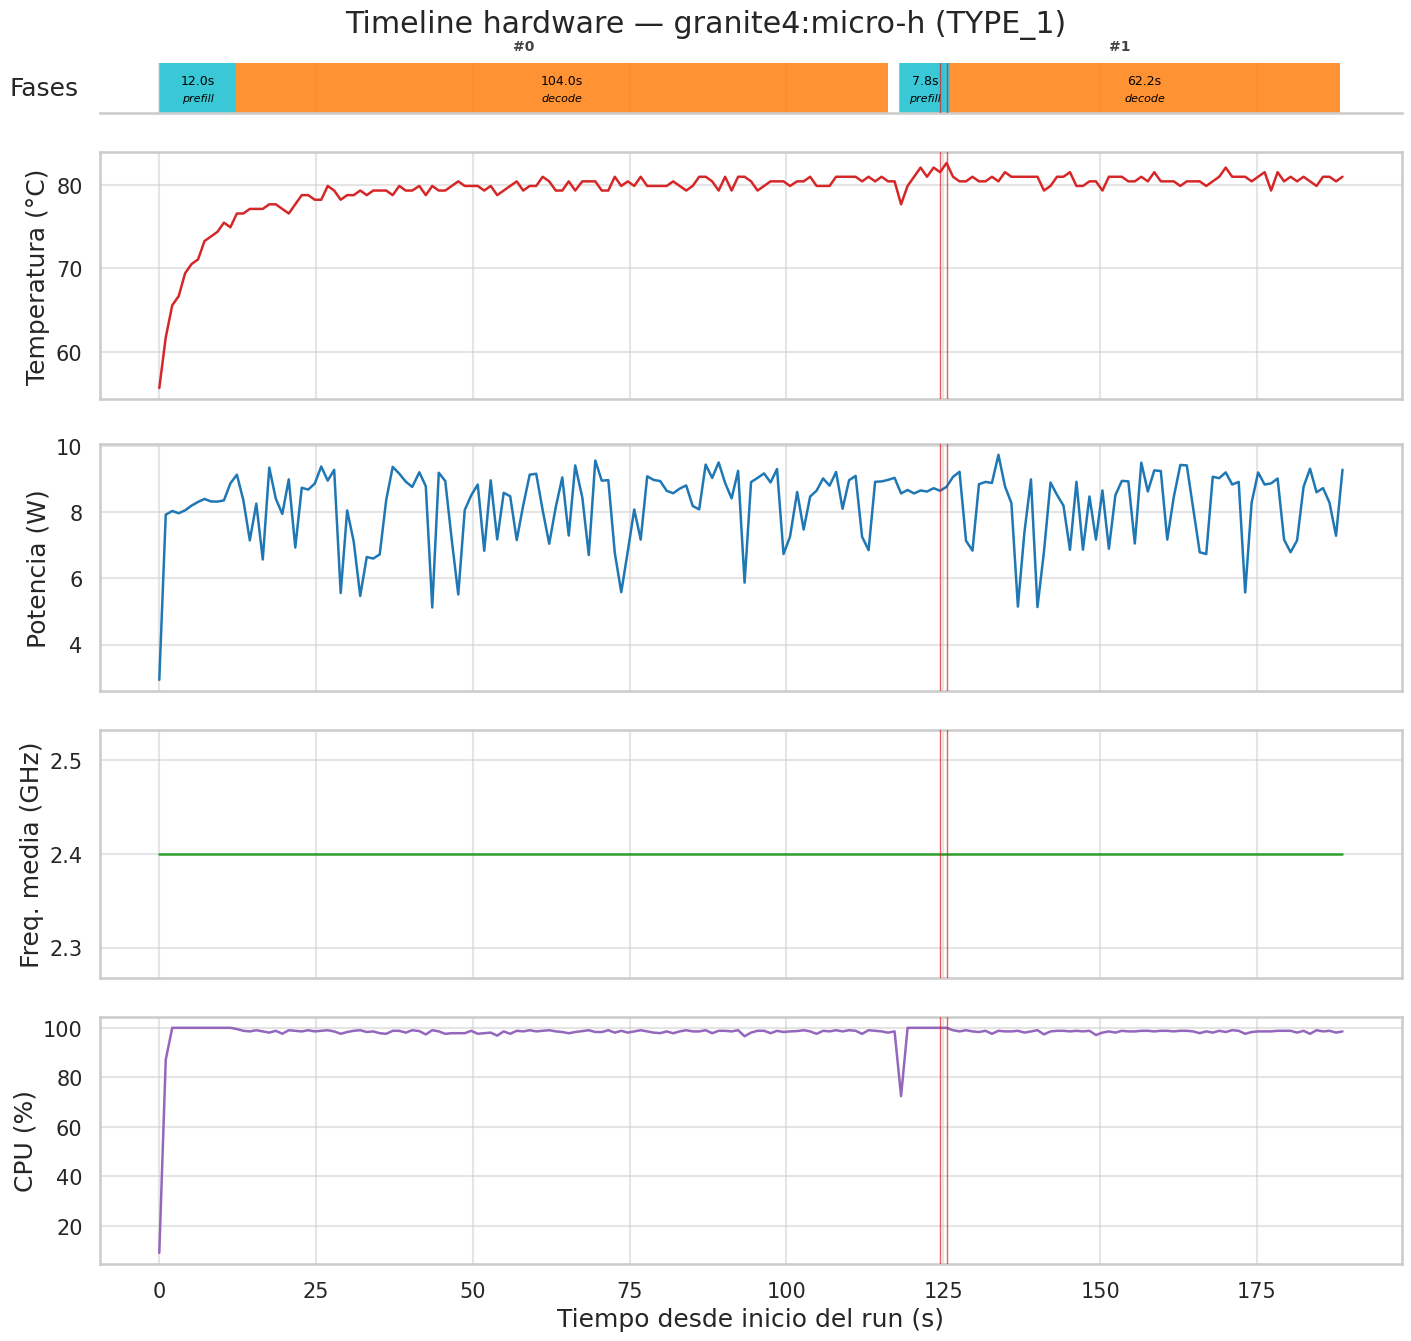

In [18]:
from monitorviz.transforms import hw_metrics_to_df

hw_df = hw_metrics_to_df(run)

fig = hw_timeline(
    hw_df, prompt_df,
    title=f"Timeline hardware — {run.model_short} ({run.summary.test_type})",
)


## Comparativa de estilos de anotación de prompts

Las cuatro alternativas para anotar prompts en la timeline. Por defecto se usa `strip`, pero puedes cambiar a las demás si te conviene en una gráfica concreta.

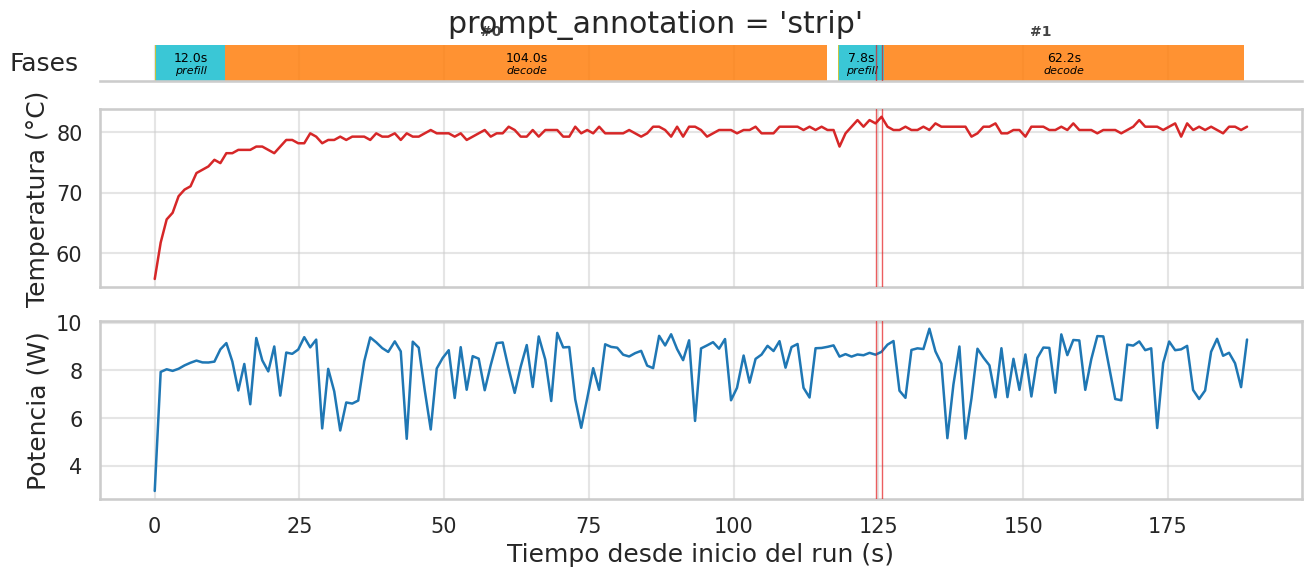

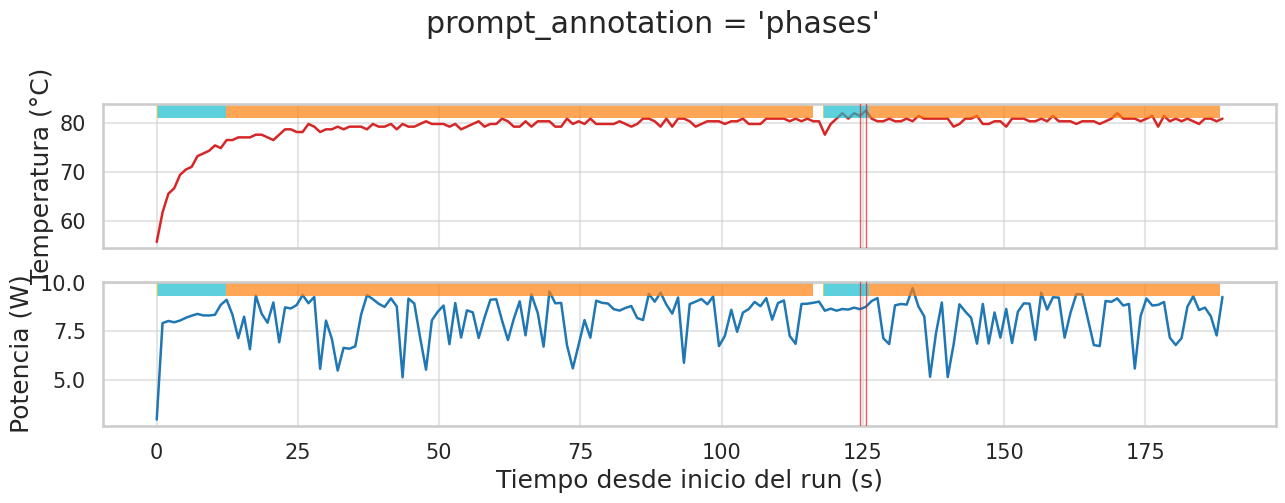

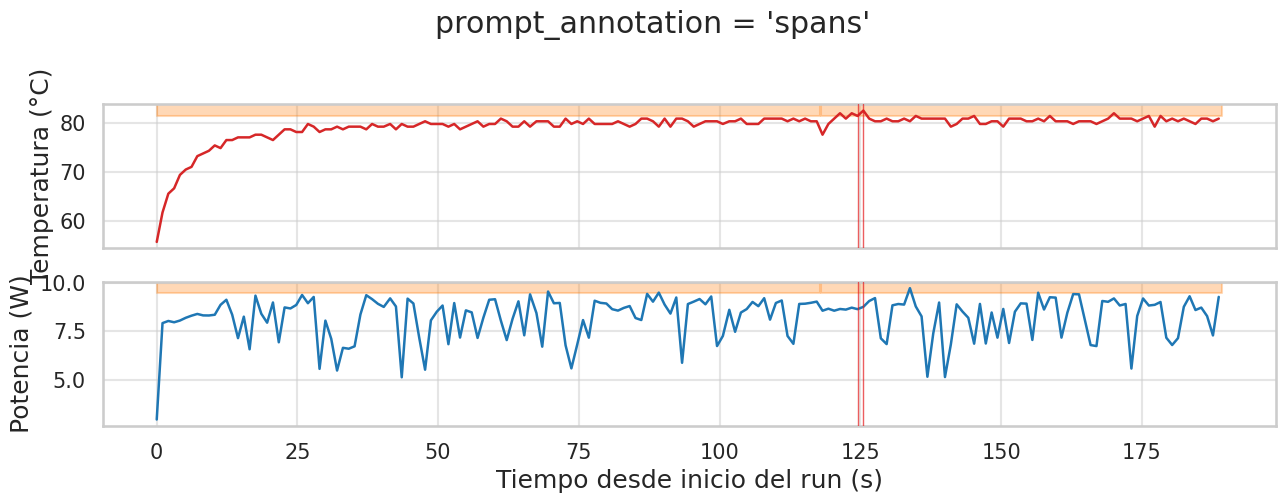

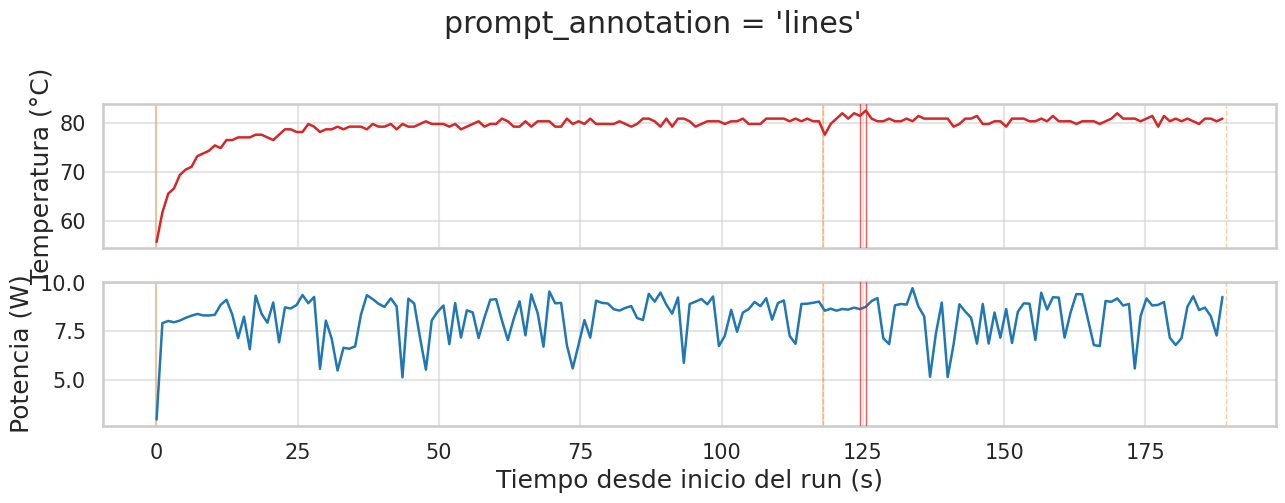

In [19]:
for annot in ["strip", "phases", "spans", "lines"]:
    fig = hw_timeline(
        hw_df, prompt_df,
        metrics=("temperature_c", "internal_power_w"),  # 2 paneles para ahorrar espacio
        prompt_annotation=annot,
        title=f"prompt_annotation = {annot!r}",
        figsize=(13, 5.5 if annot == "strip" else 5),
    )
    plt.show()


## Memoria y swap a lo largo del run

Uso de RAM y swap durante la inferencia.

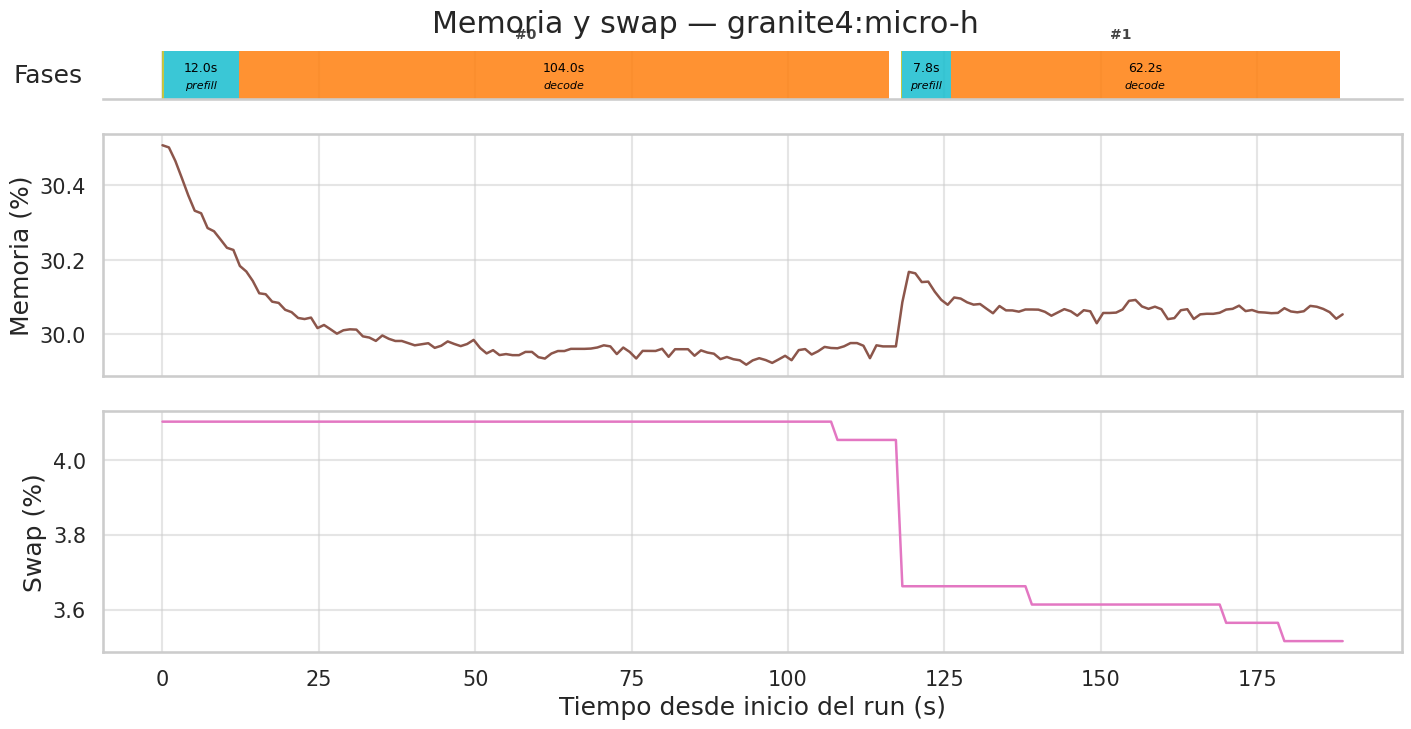

In [20]:
fig = memory_timeline(
    hw_df, prompt_df,
    title=f"Memoria y swap — {run.model_short}",
)


## CPU vs memoria (correlación)

Doble eje Y para detectar si la presión de memoria precede a la saturación de CPU.

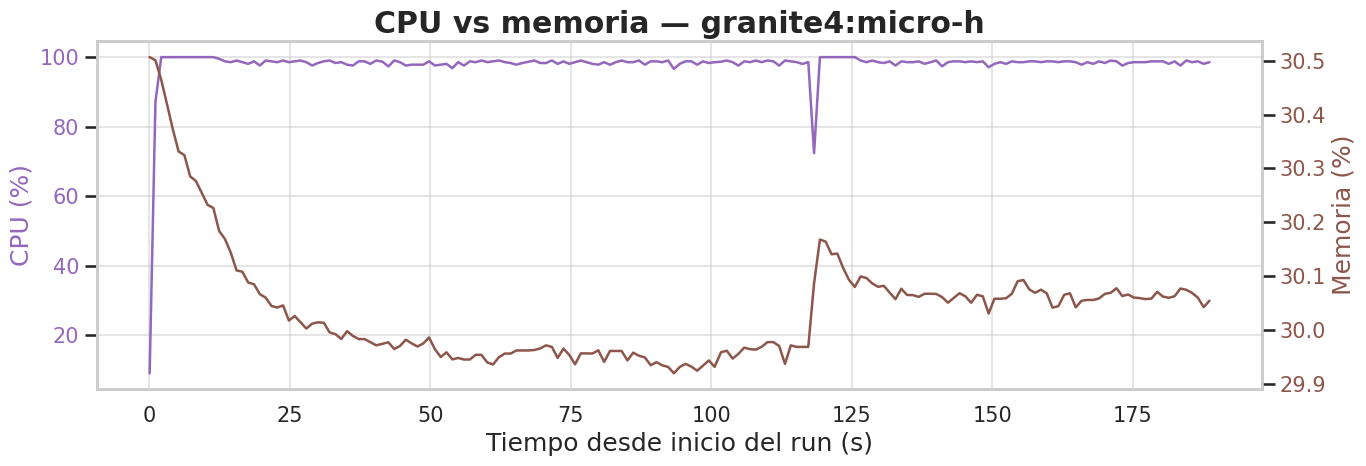

In [21]:
fig = cpu_memory_dual(hw_df, title=f"CPU vs memoria — {run.model_short}")


## Frecuencia per-core

Para ver si hay desequilibrio entre cores durante la inferencia.

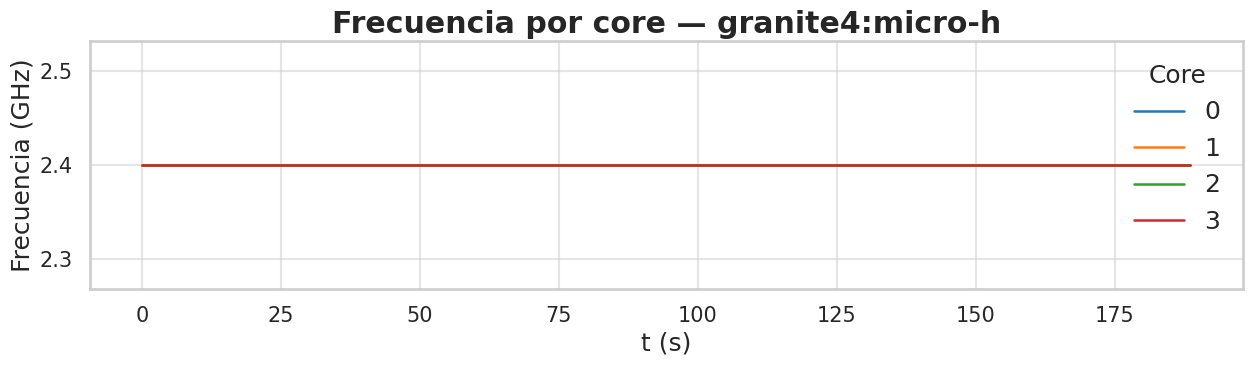

In [22]:
from monitorviz.transforms import hw_freq_long

freq_long = hw_freq_long(run)

fig = hw_freq_panel(freq_long, title=f"Frecuencia por core — {run.model_short}")

## Distribuciones de inferencia

Latencia por prompt y throughput.

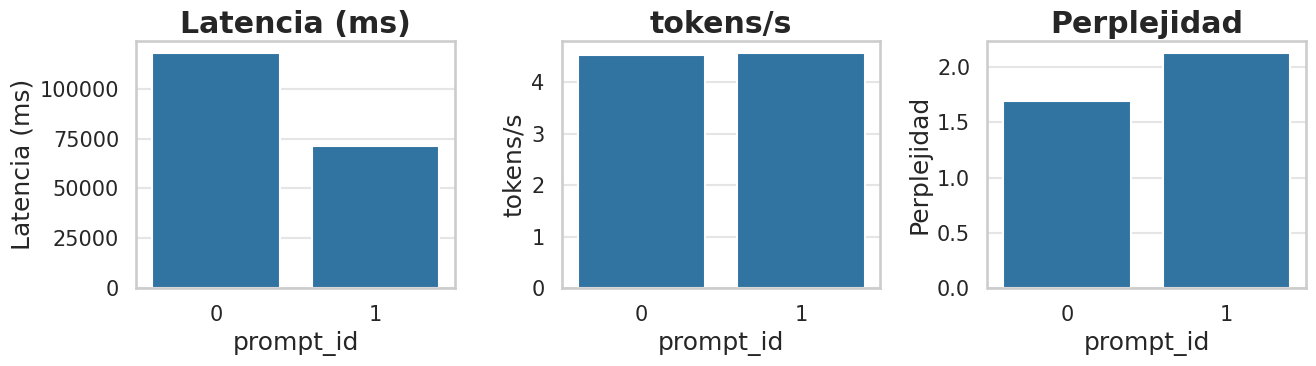

In [23]:
fig = inference_summary_panel(prompt_df)

## Perplejidad a lo largo de la respuesta

Logprob de cada token por su posición en la respuesta. Útil para ver si la
confianza del modelo cae al final de respuestas largas.

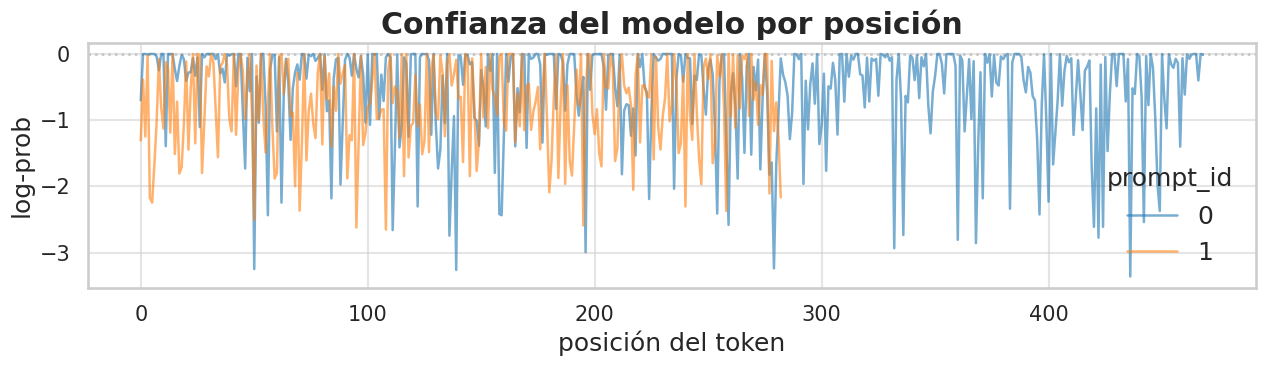

In [24]:
from monitorviz.transforms import tokens_to_df

tok_df = tokens_to_df(run)

fig = logprob_panel(tok_df, title="Confianza del modelo por posición")

## Resumen agregado

Si esto fuera un `RunCollection`, este sería el contenido de `summary_df()`
para este run. Lo construimos manualmente para validar.

In [10]:
from monitorviz.transforms import RunCollection

coll = RunCollection(runs=[run])
summary = coll.summary_df()
summary.T  # transpuesta para que quepa en pantalla

,0
run_id,run_granite_ollama
engine,OLLAMA
model_short,granite4:micro-h
test_type,TYPE_1
batch_size,511
context_size,1024
seed,42
temperature,0.0
hardware_period_s,0.5
fan,None
